## **LOAD DATA**

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from scipy import stats

## **Data Preparation**

In [ ]:
df = pd.read_csv('../data/climate_change_data.csv')
df.head(10)

,Date,Location,Country,Temperature,CO2 Emissions,Sea Level Rise,Precipitation,Humidity,Wind Speed
0,2000-01-01 00:00:00.000000000,New Williamtown,Latvia,10.688986,403.118903,0.717506,13.835237,23.631256,18.492026
1,2000-01-01 20:09:43.258325832,North Rachel,South Africa,13.814430,396.663499,1.205715,40.974084,43.982946,34.249300
2,2000-01-02 16:19:26.516651665,West Williamland,French Guiana,27.323718,451.553155,-0.160783,42.697931,96.652600,34.124261
3,2000-01-03 12:29:09.774977497,South David,Vietnam,12.309581,422.404983,-0.475931,5.193341,47.467938,8.554563
4,2000-01-04 08:38:53.033303330,New Scottburgh,Moldova,13.210885,410.472999,1.135757,78.695280,61.789672,8.001164
5,2000-01-05 04:48:36.291629162,South Nathan,Saint Helena,6.229326,392.473317,1.122210,76.368331,48.973886,30.398908
6,2000-01-06 00:58:19.549954995,Port Richardfurt,Tuvalu,21.646738,387.648437,0.058471,9.650389,11.402284,15.720944
7,2000-01-06 21:08:02.808280828,Adambury,Australia,19.730800,448.180275,0.001415,93.360755,21.526350,29.993495
8,2000-01-07 17:17:46.066606660,Williamsonberg,Qatar,19.858114,379.618820,0.584881,6.218846,30.861949,37.519472
9,2000-01-08 13:27:29.324932493,North Thomas,Chad,14.121563,410.517072,-1.712224,15.351583,88.422794,47.922521


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10000 non-null  object 
 1   Location        10000 non-null  object 
 2   Country         10000 non-null  object 
 3   Temperature     10000 non-null  float64
 4   CO2 Emissions   10000 non-null  float64
 5   Sea Level Rise  10000 non-null  float64
 6   Precipitation   10000 non-null  float64
 7   Humidity        10000 non-null  float64
 8   Wind Speed      10000 non-null  float64
dtypes: float64(6), object(3)
memory usage: 703.3+ KB


In [46]:
df.describe()

,Temperature,CO2 Emissions,Sea Level Rise,Precipitation,Humidity,Wind Speed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,14.936034,400.220469,-0.003152,49.881208,49.771302,25.082066
std,5.030616,49.696933,0.991349,28.862417,28.929320,14.466648
min,-3.803589,182.131220,-4.092155,0.010143,0.018998,0.001732
25%,11.577991,367.109330,-0.673809,24.497516,24.713250,12.539733
50%,14.981136,400.821324,0.002332,49.818967,49.678412,24.910787
75%,18.305826,433.307905,0.675723,74.524991,75.206390,37.670260
max,33.976956,582.899701,4.116559,99.991900,99.959665,49.997664


In [47]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)

print("\nDate range:", df['Date'].min(), "to", df['Date'].max())
print("Number of unique locations:", df['Location'].nunique())
print("Number of unique countries:", df['Country'].nunique())


Date range: 2000-01-01 00:00:00 to 2022-12-31 00:00:00
Number of unique locations: 7764
Number of unique countries: 243


In [48]:
df.dtypes

Date              datetime64[ns]
Location                  object
Country                   object
Temperature              float64
CO2 Emissions            float64
Sea Level Rise           float64
Precipitation            float64
Humidity                 float64
Wind Speed               float64
dtype: object

In [49]:
df.isnull().sum()

Date              0
Location          0
Country           0
Temperature       0
CO2 Emissions     0
Sea Level Rise    0
Precipitation     0
Humidity          0
Wind Speed        0
dtype: int64

## **EDA**

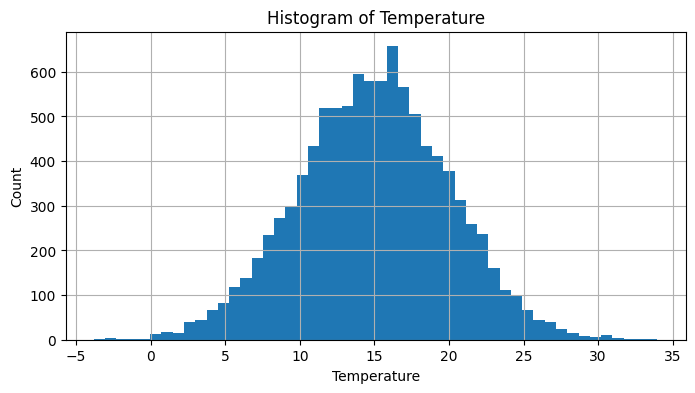

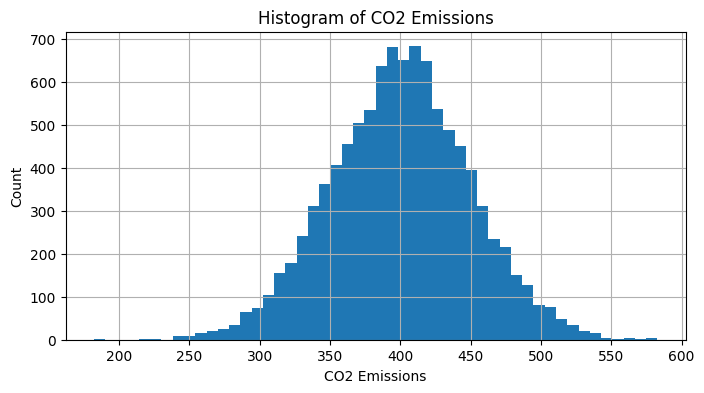

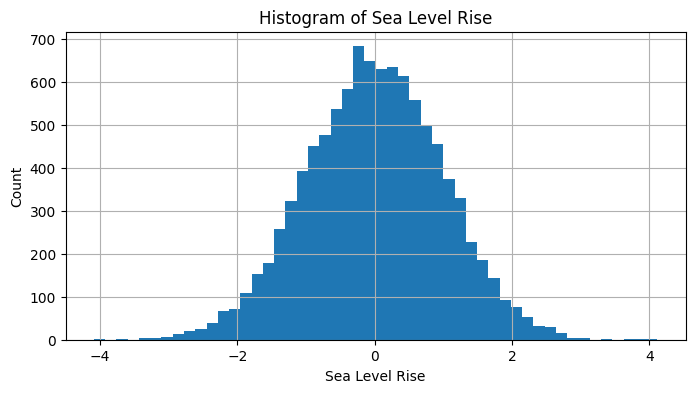

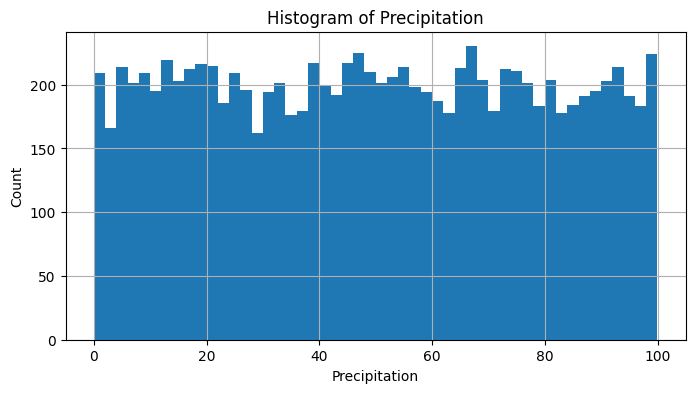

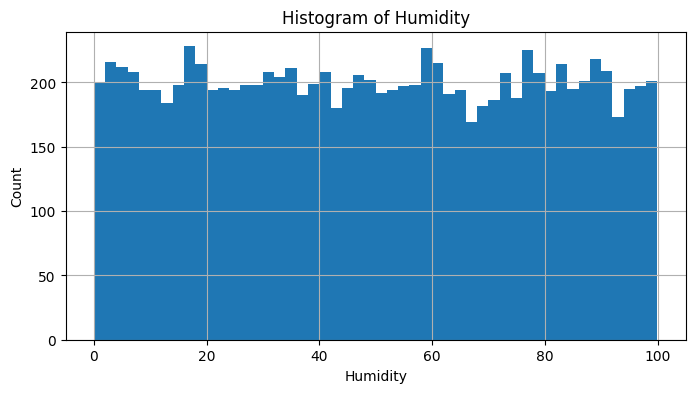

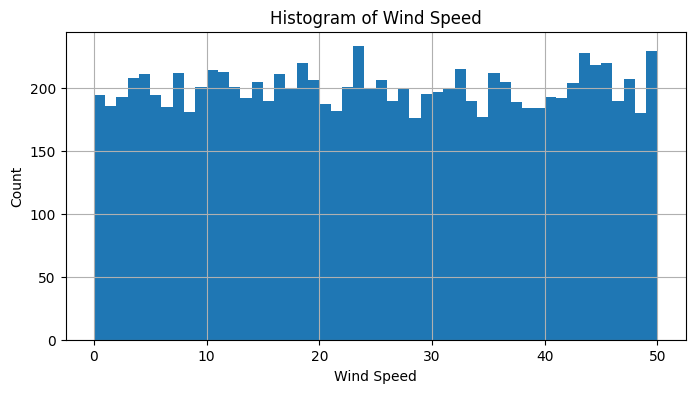

In [50]:
numeric_cols = ['Temperature', 'CO2 Emissions', 'Sea Level Rise', 'Precipitation', 'Humidity', 'Wind Speed']

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

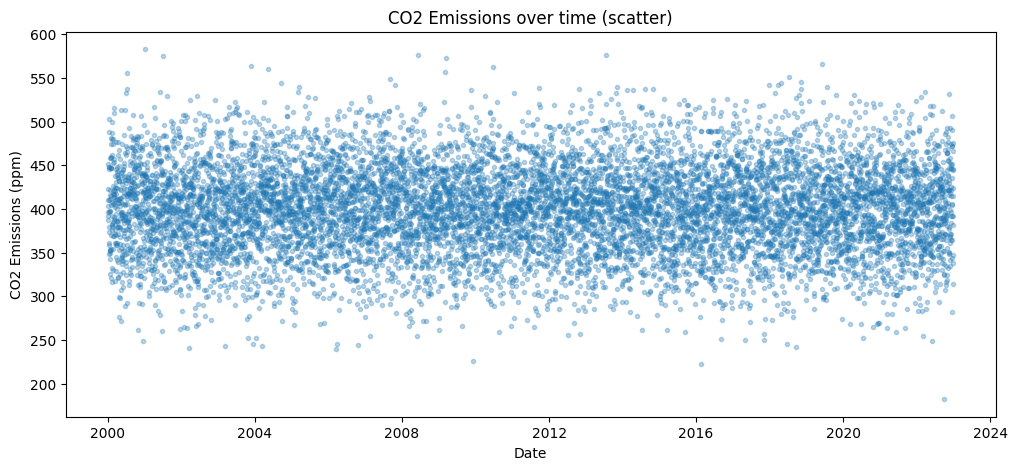

In [51]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['CO2 Emissions'], marker='.', linestyle='none', alpha=0.3)
plt.title("CO2 Emissions over time (scatter)")
plt.xlabel("Date")
plt.ylabel("CO2 Emissions (ppm)")
plt.show()

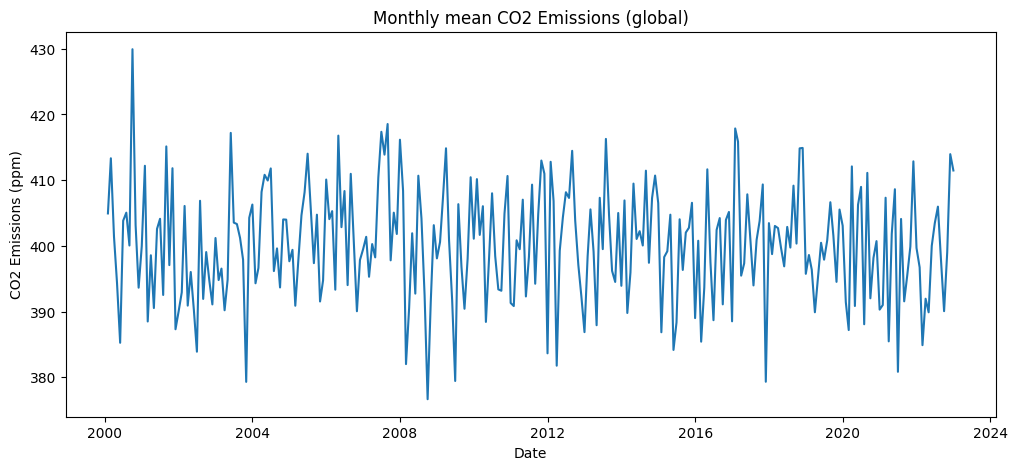

In [54]:
df_time = df.set_index('Date').resample('ME').mean(numeric_only=True)
plt.figure(figsize=(12,5))
plt.plot(df_time.index, df_time['CO2 Emissions'])
plt.title("Monthly mean CO2 Emissions (global)")
plt.xlabel("Date")
plt.ylabel("CO2 Emissions (ppm)")
plt.show()

Correlation matrix           feature  Temperature  CO2 Emissions  Sea Level Rise  Precipitation  \
0     Temperature     1.000000      -0.002775        0.011663       0.004916   
1   CO2 Emissions    -0.002775       1.000000       -0.004751      -0.007443   
2  Sea Level Rise     0.011663      -0.004751        1.000000      -0.000249   
3   Precipitation     0.004916      -0.007443       -0.000249       1.000000   
4        Humidity    -0.015737      -0.003661       -0.007610       0.003732   
5      Wind Speed     0.021779      -0.003990        0.011789      -0.018798   

   Humidity  Wind Speed  
0 -0.015737    0.021779  
1 -0.003661   -0.003990  
2 -0.007610    0.011789  
3  0.003732   -0.018798  
4  1.000000    0.028591  
5  0.028591    1.000000  


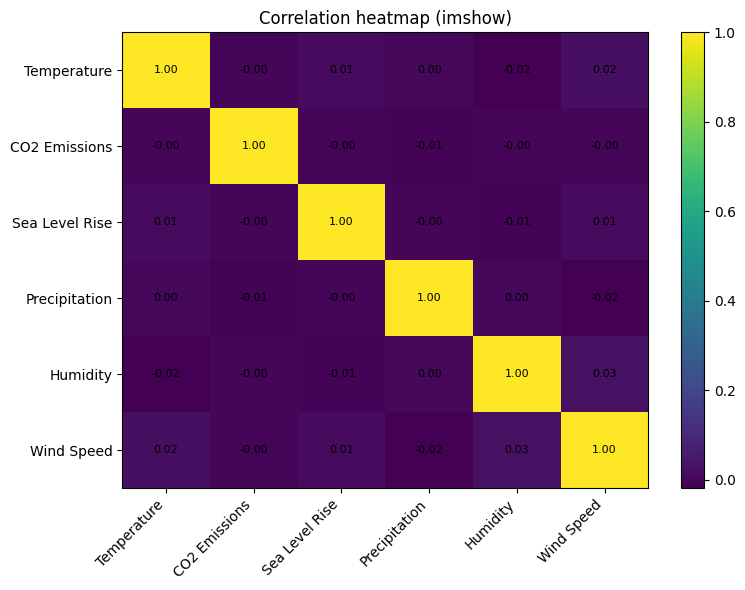

In [55]:
corr = df[numeric_cols].corr()
print("Correlation matrix", corr.reset_index().rename(columns={'index':'feature'}))

plt.figure(figsize=(8,6))
plt.imshow(corr.values, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap (imshow)")

for (i, j), val in np.ndenumerate(corr.values):
    plt.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

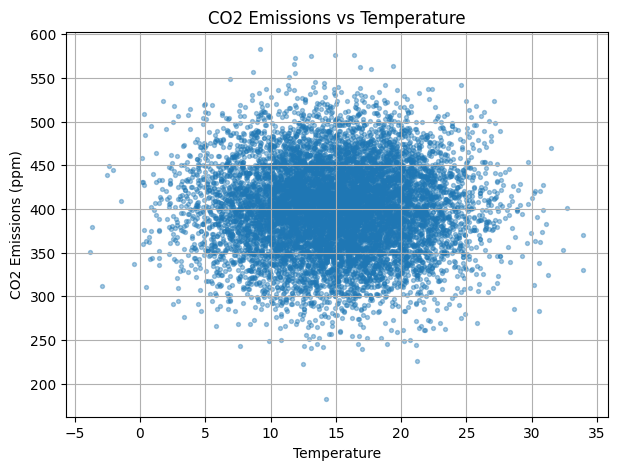

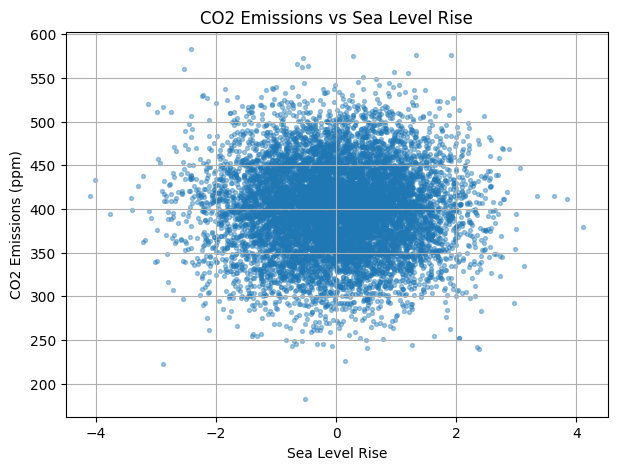

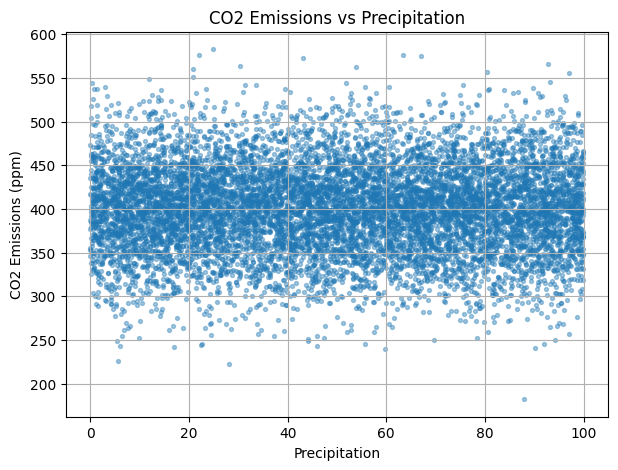

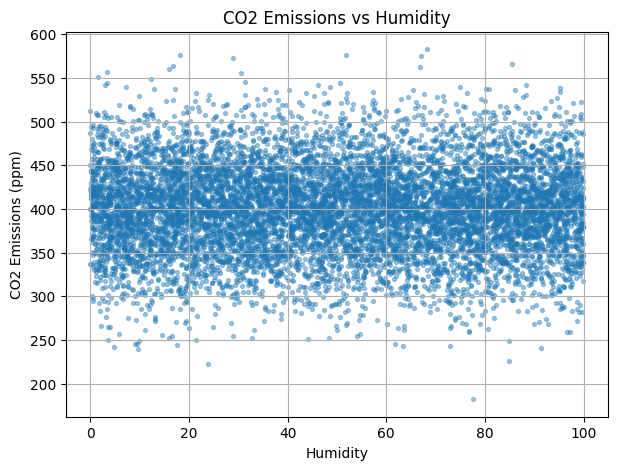

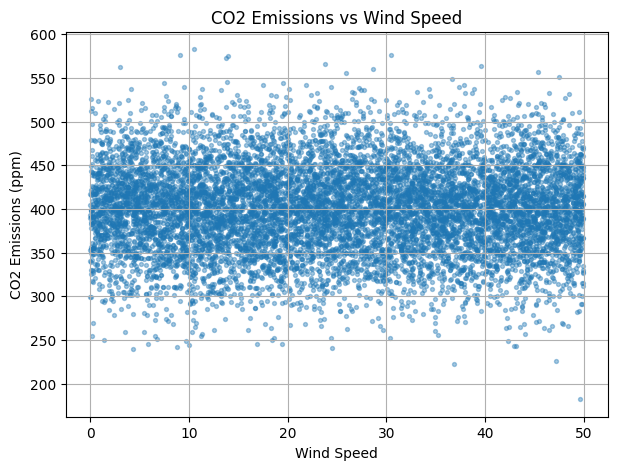

In [56]:
predictors = ['Temperature', 'Sea Level Rise', 'Precipitation', 'Humidity', 'Wind Speed']
for col in predictors:
    plt.figure(figsize=(7,5))
    plt.scatter(df[col], df['CO2 Emissions'], s=8, alpha=0.4)
    plt.title(f"CO2 Emissions vs {col}")
    plt.xlabel(col)
    plt.ylabel("CO2 Emissions (ppm)")
    plt.grid(True)
    plt.show()

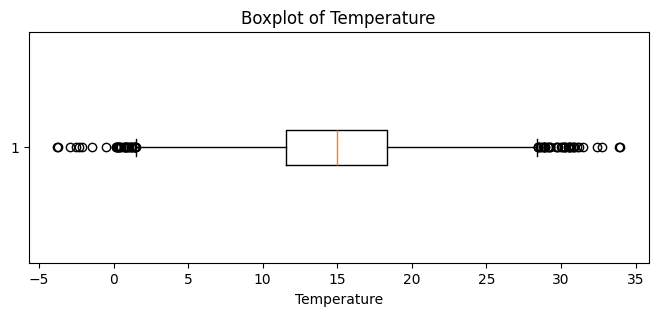

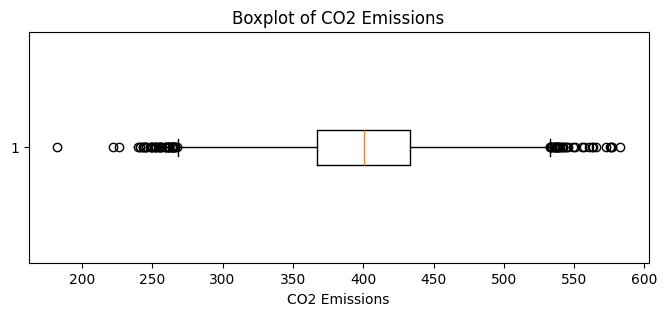

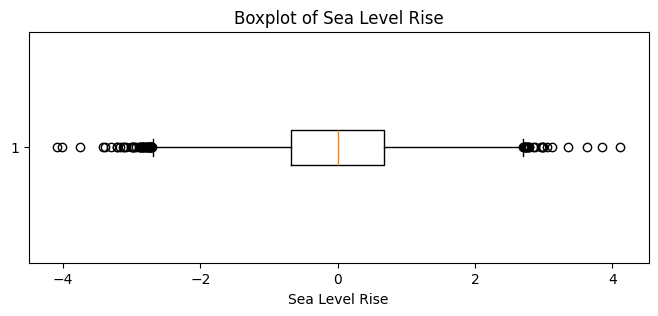

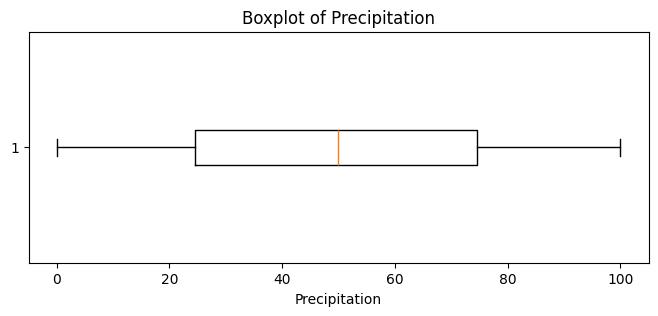

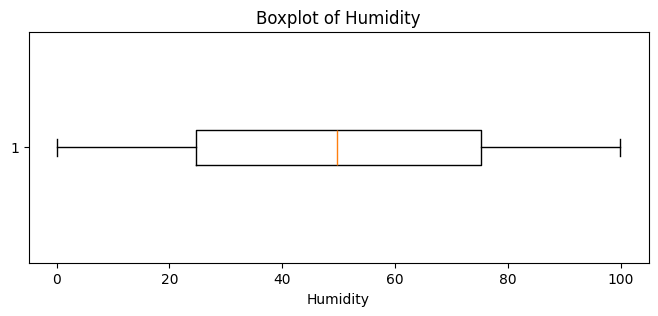

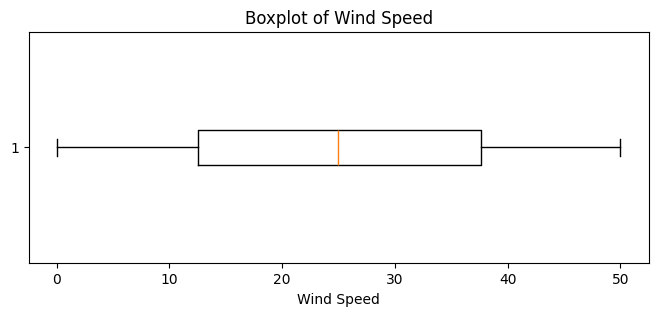

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

Average CO2 per Country (top 20)                                          Country  CO2 Emissions
0                                         Belize     422.184798
1                                           Mali     420.245877
2                                        Myanmar     420.009657
3                                      Hong Kong     419.108583
4                            Trinidad and Tobago     418.341029
5                                        Vietnam     416.914501
6                               Marshall Islands     416.481269
7                   Svalbard & Jan Mayen Islands     415.248927
8                                           Oman     415.168981
9                                         Monaco     414.462741
10                                      Zimbabwe     414.444619
11                                         Nauru     413.935086
12                                      Guernsey     413.598612
13                                         Kenya     413.529245
14  Sou

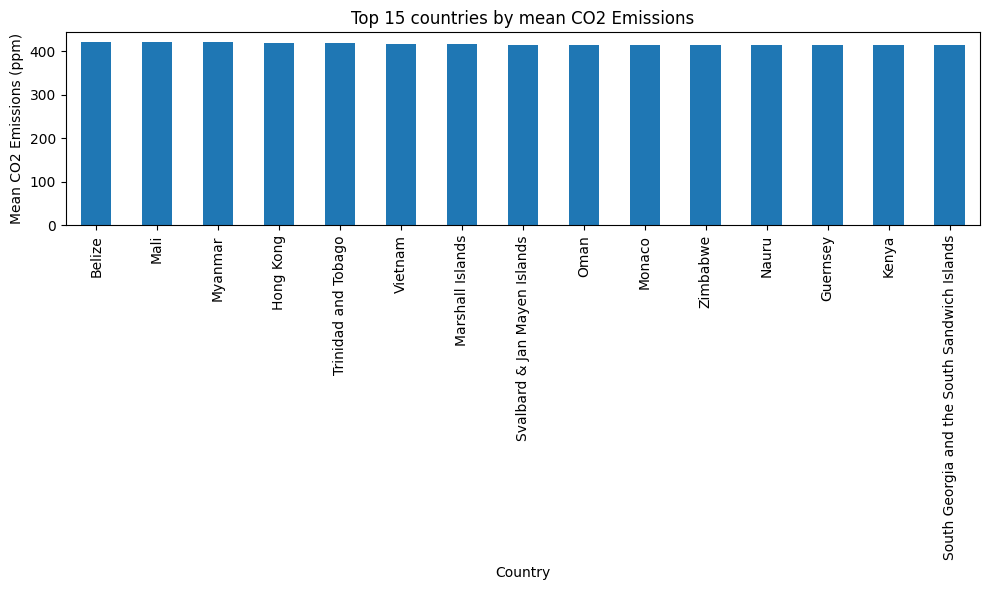

In [58]:
country_mean = df.groupby('Country')['CO2 Emissions'].mean().sort_values(ascending=False)
print("Average CO2 per Country (top 20)", country_mean.reset_index().head(20))

plt.figure(figsize=(10,6))
country_mean.head(15).plot(kind='bar')
plt.title("Top 15 countries by mean CO2 Emissions")
plt.xlabel("Country")
plt.ylabel("Mean CO2 Emissions (ppm)")
plt.tight_layout()
plt.show()

In [ ]:
co2 = df['CO2 Emissions']

Q1 = co2.quantile(0.25)
Q3 = co2.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers_iqr = df[(co2 < lower) | (co2 > upper)]
print(f"\nIQR outliers: {len(outliers_iqr)} rows (CO2 < {lower:.2f} or > {upper:.2f})")


IQR outliers: 82 rows (CO2 < 267.81 or > 532.61)


In [63]:
z_scores = np.abs(stats.zscore(co2))
outliers_z = df[z_scores > 3]
print(f"Z-score outliers (|z|>3): {len(outliers_z)} rows")

Z-score outliers (|z|>3): 29 rows


## **Pre-Modeling**

In [ ]:
#Feature Engineering
df_fe = df.copy()
df_fe['Year'] = df_fe['Date'].dt.year
df_fe['Month'] = df_fe['Date'].dt.month
df_fe['DayOfYear'] = df_fe['Date'].dt.dayofyear

df_fe = df_fe.set_index('Date').sort_index()
df_fe['CO2_roll_3m'] = df_fe['CO2 Emissions'].rolling(window=3, min_periods=1).mean()
df_fe['CO2_lag_1'] = df_fe['CO2 Emissions'].shift(1)
df_fe = df_fe.reset_index()

df_fe[['Date','CO2 Emissions','CO2_roll_3m','CO2_lag_1']].head(10)

,Date,CO2 Emissions,CO2_roll_3m,CO2_lag_1
0,2000-01-01 00:00:00.000000000,403.118903,403.118903,NaN
1,2000-01-01 20:09:43.258325832,396.663499,399.891201,403.118903
2,2000-01-02 16:19:26.516651665,451.553155,417.111852,396.663499
3,2000-01-03 12:29:09.774977497,422.404983,423.540546,451.553155
4,2000-01-04 08:38:53.033303330,410.472999,428.143712,422.404983
5,2000-01-05 04:48:36.291629162,392.473317,408.450433,410.472999
6,2000-01-06 00:58:19.549954995,387.648437,396.864918,392.473317
7,2000-01-06 21:08:02.808280828,448.180275,409.434010,387.648437
8,2000-01-07 17:17:46.066606660,379.618820,405.149177,448.180275
9,2000-01-08 13:27:29.324932493,410.517072,412.772056,379.618820


In [ ]:
#Define Features and Target
model_df = df_fe.dropna(subset=['CO2_lag_1']).copy()
X = model_df[['Temperature','Sea Level Rise','Precipitation','Humidity','Wind Speed','CO2_lag_1']]
y = model_df['CO2 Emissions']

#Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Multi-Model Comparison**

In [79]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=200, 
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

# Cross-validation (5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv)
    rmse_scores = np.sqrt(-scores)
    results.append([name, rmse_scores.mean(), rmse_scores.std()])

df_cv = pd.DataFrame(results, columns=["Model", "RMSE Mean", "RMSE Std"])
print(df_cv)

              Model  RMSE Mean  RMSE Std
0  LinearRegression  49.733658  0.207184
1      RandomForest  50.532835  0.213261
2  GradientBoosting  49.966340  0.234998
3           XGBoost  50.832540  0.324027


### **Hyperparameter Tuning (RF + XGB)**

In [ ]:
#Random Forest Tuning
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X, y)
print("Best RF params:", rf_search.best_params_)
print("Best RF RMSE:", np.sqrt(-rf_search.best_score_))

Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
Best RF RMSE: 49.755911078273535


In [ ]:
#XGBoost Tuning
xgb = xgb.XGBRegressor(random_state=42)

xgb_params = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=20,
    cv=3,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X, y)
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB RMSE:", np.sqrt(-xgb_search.best_score_))

Best XGB params: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best XGB RMSE: 49.75677722753567


### **MODEL RE-EVALUATION**

In [82]:
best_models = {
    "LinearRegression": LinearRegression(),
    "RandomForest_Tuned": rf_search.best_estimator_,
    "XGBoost_Tuned": xgb_search.best_estimator_
}

results2 = []

for name, model in best_models.items():
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv)
    rmse_scores = np.sqrt(-scores)
    results2.append([name, rmse_scores.mean(), rmse_scores.std()])

df_compare = pd.DataFrame(results2, columns=["Model", "RMSE Mean", "RMSE Std"])
df_compare

,Model,RMSE Mean,RMSE Std
0,LinearRegression,49.733658,0.207184
1,RandomForest_Tuned,49.724967,0.190294
2,XGBoost_Tuned,49.731245,0.191306


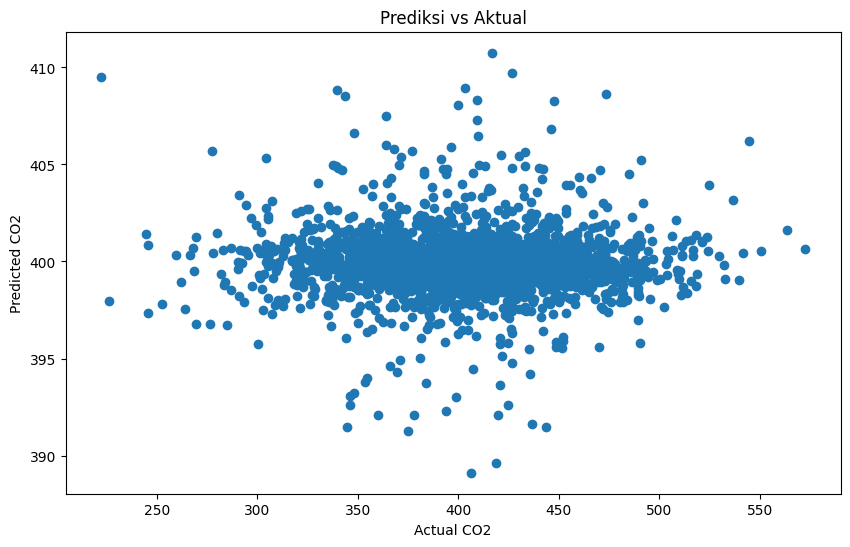

In [83]:
best_model = xgb_search.best_estimator_
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

plt.figure(figsize=(10,6))
plt.scatter(y_test, preds)
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Prediksi vs Aktual")
plt.show()

### **Feature Importances**

In [91]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
}).sort_values(by="importance", ascending=False)
importance_df

,feature,importance
5,CO2_lag_1,0.173099
4,Wind Speed,0.171556
2,Precipitation,0.166102
3,Humidity,0.165247
1,Sea Level Rise,0.164923
0,Temperature,0.159074


In [93]:
importance_df.to_csv("results/feature_importance.csv", index=False)